In [292]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

In [293]:
crypto_symbol = "BTC-USD"
btc_data = yf.download(crypto_symbol, period='1y', interval='1d')


[*********************100%***********************]  1 of 1 completed


In [294]:
data = btc_data["Close"]
data.head()

Ticker,BTC-USD
Date,
2024-05-01,58254.011719
2024-05-02,59123.433594
2024-05-03,62889.835938
2024-05-04,63891.472656
2024-05-05,64031.132812


In [295]:
data.isna().sum()

Ticker
BTC-USD    0
dtype: int64

In [296]:
data.duplicated().sum()

np.int64(0)

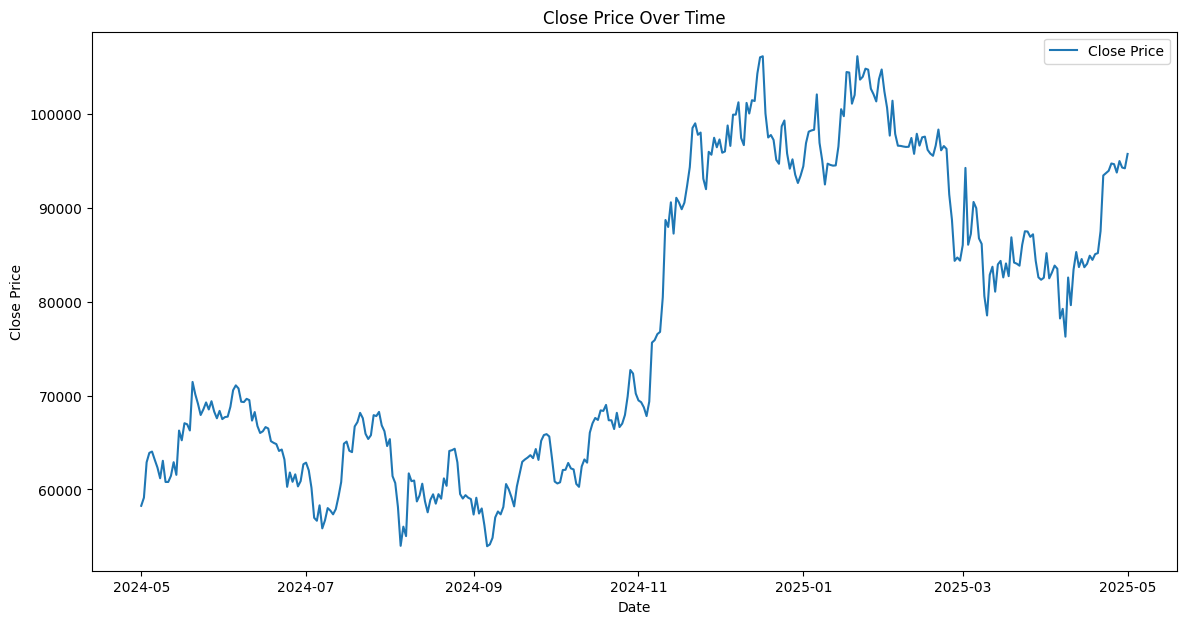

In [297]:
# Plotting the original Close price
plt.figure(figsize=(14, 7))
plt.plot(data.index, data["BTC-USD"], label='Close Price')
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


In [298]:
result_original = adfuller(data["BTC-USD"])

print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")

if result_original[1] < 0.05:
    print(f"Interpretation: The original series is Stationary.\n")
else:
    print(f"Interpretation: The original series is Non-Stationary.\n")

ADF Statistic (Original): -1.2879
p-value (Original): 0.6347
Interpretation: The original series is Non-Stationary.



In [299]:
# Apply first-order differencing
# .diff() calculates the difference between the current and previous row in that column.
# ARIMA model works fine on stationary series

data["Close_Diff"] = data["BTC-USD"].diff()
data.head()

C:\Users\A cer\AppData\Local\Temp\ipykernel_17288\186411726.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Close_Diff"] = data["BTC-USD"].diff()


Ticker,BTC-USD,Close_Diff
Date,,
2024-05-01,58254.011719,NaN
2024-05-02,59123.433594,869.421875
2024-05-03,62889.835938,3766.402344
2024-05-04,63891.472656,1001.636719
2024-05-05,64031.132812,139.660156


In [300]:
result_diff = adfuller(data["Close_Diff"].dropna())
print(f"ADF Statistic (Original): {result_diff[0]:.4f}")
print(f"p-value (Original): {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print(f"Interpretation: The differenced series is Stationary.\n")
else:
    print(f"Interpretation: The differenced series is Non-Stationary.\n")

ADF Statistic (Original): -20.6147
p-value (Original): 0.0000
Interpretation: The differenced series is Stationary.



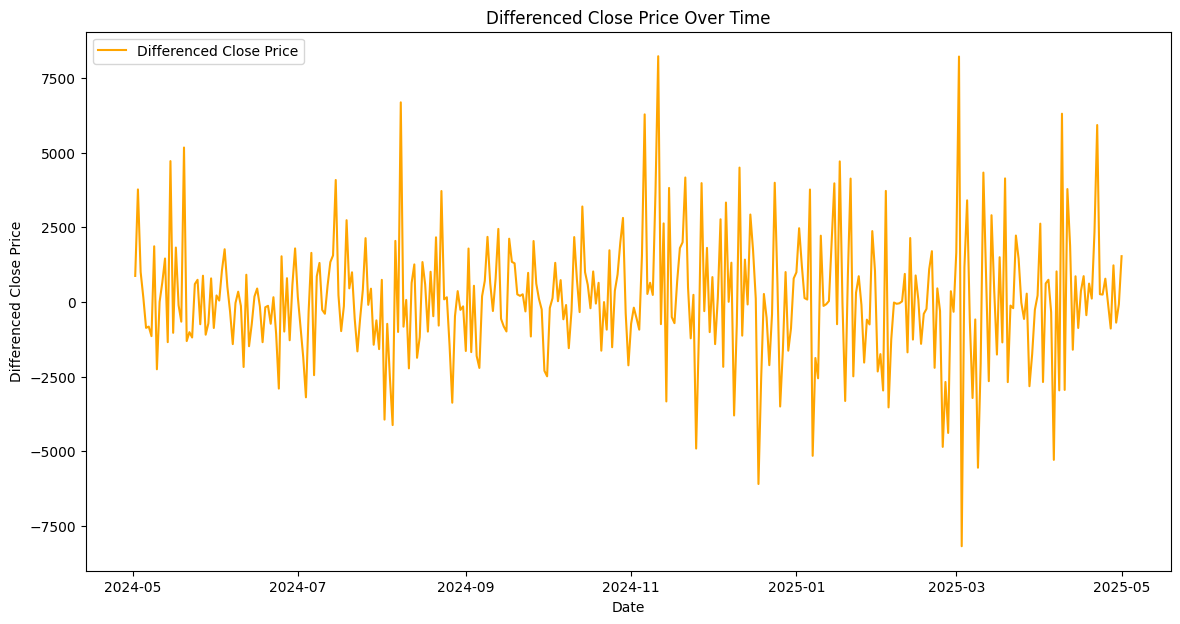

In [301]:
# Plotting the differenced Close price

plt.figure(figsize=(14,7))
plt.plot(data.index, data["Close_Diff"], label='Differenced Close Price', color='orange')
plt.title('Differenced Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Differenced Close Price')
plt.legend()
plt.show()

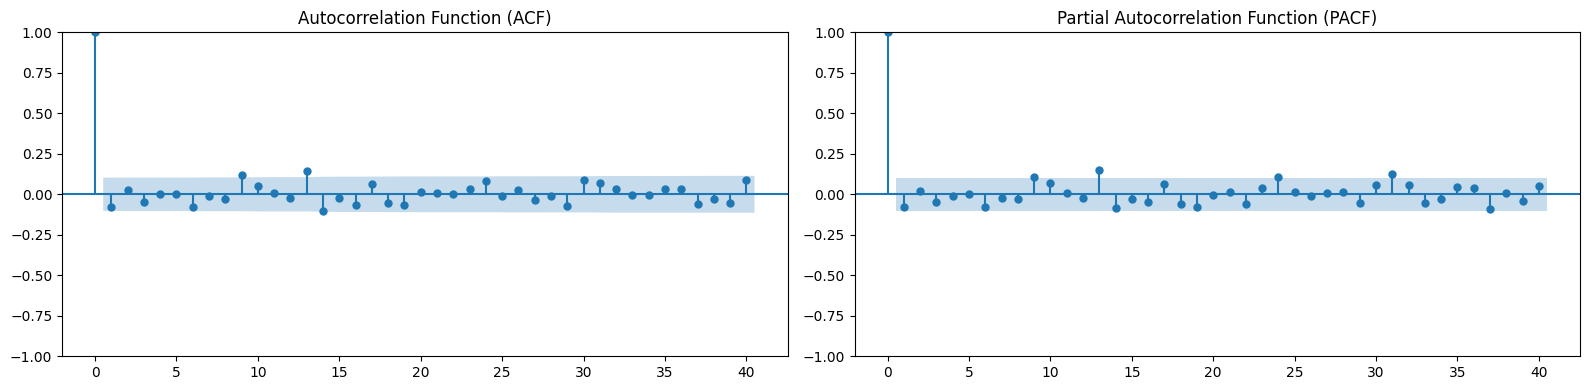

In [302]:
# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF( Auto Corelation Function ) plot
plot_acf(data['Close_Diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot( Partial Auto Corelation Function )
plot_pacf(data['Close_Diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [303]:
# Split data into train and test

train_size = int(len(data)*0.8)
train = data["BTC-USD"][:train_size]
test = data["BTC-USD"].iloc[train_size:].dropna()

# train.index = pd.to_datetime(train.index)
# train = train.asfreq('D')  # Daily frequency

# Fit ARIMA model
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()
model_fit.summary()

C:\anaconda3\envs\tfenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\anaconda3\envs\tfenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\anaconda3\envs\tfenv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\anaconda3\envs\tfenv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\anaconda3\envs\tfenv\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters fo

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                BTC-USD   No. Observations:                  292
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -2605.713
Date:                Thu, 01 May 2025   AIC                           5221.425
Time:                        15:43:28   BIC                           5239.792
Sample:                    05-01-2024   HQIC                          5228.783
                         - 02-16-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0708      0.021    -50.460      0.000      -1.112      -1.029
ar.L2         -0.9402      0.021    -44.670      0.000      -0.981      -0.899
ma.L1          1.0786      0.032     33.635      0.000       1.016       1.141
ma.L2          0.9970      0.058     17.265      0.000       0.884       1.110
sigma2      3.582e+06   1.37e-08   2.62e+14      0.000    3.58e+06    3.58e+06
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                38.38
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               2.01   Skew:                             0.40
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.58
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.06e+30. Standard errors may be unstable.
"""

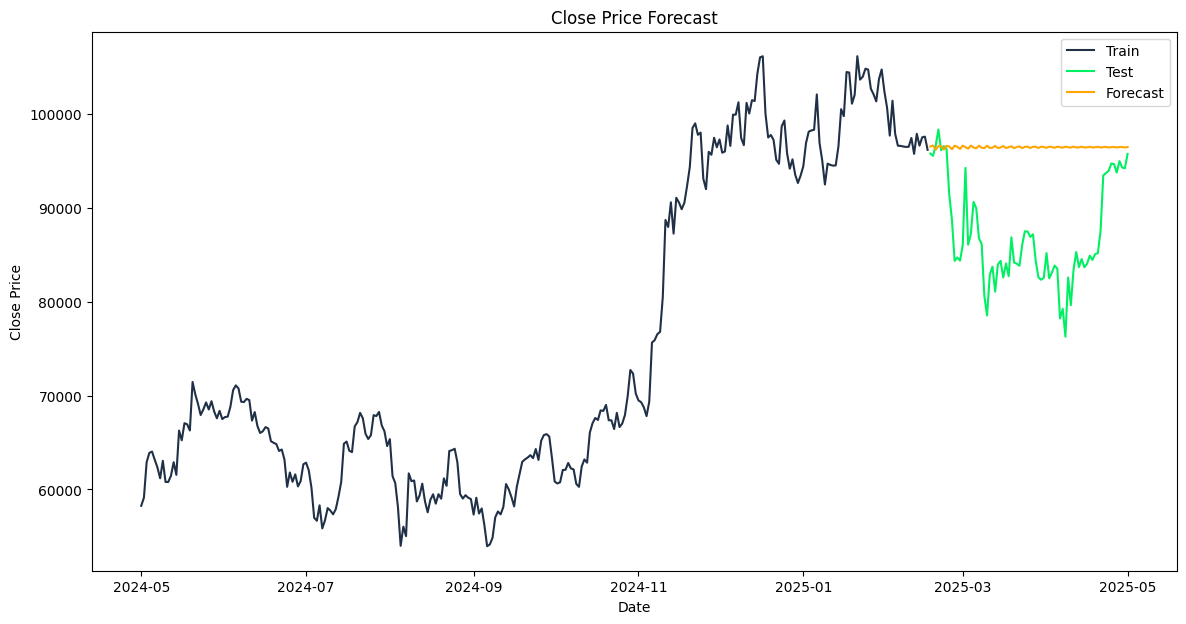

In [304]:
# forecast

forecast = model_fit.forecast(steps=len(test))

# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train, label='Train', color='#203147')
plt.plot(test.index, test, label='Test', color='#01ef63')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()



In [305]:
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")


AIC: 5221.425283883293
BIC: 5239.79190021915


In [306]:
forecast = forecast[:len(test)]
test_close = test[:len(forecast)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print(f"RMSE: {rmse:.4f}")

RMSE: 10878.5939


In [307]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test, forecast)
print(f"MAPE: {mape*100:.2f}%")

MAPE: 11.39%
